In [1]:
! mkdir -p /root/.kaggle 


In [2]:
! mv kaggle.json /root/.kaggle

In [3]:
! kaggle competitions download -c dogs-vs-cats

  0% 0.00/86.8k [00:00<?, ?B/s]
100% 86.8k/86.8k [00:00<00:00, 32.1MB/s]
 95% 258M/271M [00:01<00:00, 197MB/s]
100% 271M/271M [00:01<00:00, 189MB/s]
100% 542M/543M [00:04<00:00, 174MB/s]
100% 543M/543M [00:04<00:00, 135MB/s]


In [4]:
!unzip -q train.zip

In [8]:
import os
os.mkdir("train_data")
os.mkdir("train_data/cat")
os.mkdir("train_data/dog")

In [9]:
from shutil import copy

In [10]:
for imageName in os.listdir("train/"):
  if "cat" in imageName: 
    copy("train/" + imageName, "train_data/cat")
  elif 'dog' in imageName:
    copy("train/" + imageName, "train_data/dog")
  else:
    print(imageName)

In [11]:
len(os.listdir('train_data/cat'))

12500

In [12]:
import tensorflow as tf

In [13]:
idg =tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,rotation_range=90,
                     width_shift_range=0.1,
                     height_shift_range=0.1,
                     zoom_range=0.2)

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

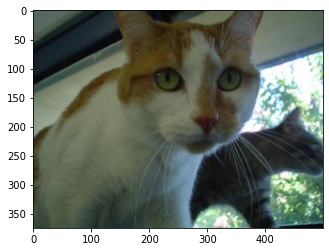

In [15]:
timage = cv2.imread("train/cat.10082.jpg")
timage = cv2.cvtColor(timage, cv2.COLOR_BGR2RGB)
timage = np.expand_dims(timage, axis=0)
timage.shape
plt.imshow(timage[0])

In [18]:
# ! rm -rf testAug
! mkdir testAug

In [19]:
i = 0 
for _ in idg.flow(timage, batch_size=1, save_to_dir="testAug"):
  i = i + 1
  if i > 21:
    break

In [20]:
testI = []
for i in os.listdir("testAug"):
  i = cv2.cvtColor(cv2.imread("testAug/" + i), cv2.COLOR_BGR2RGB)
  testI.append(i)

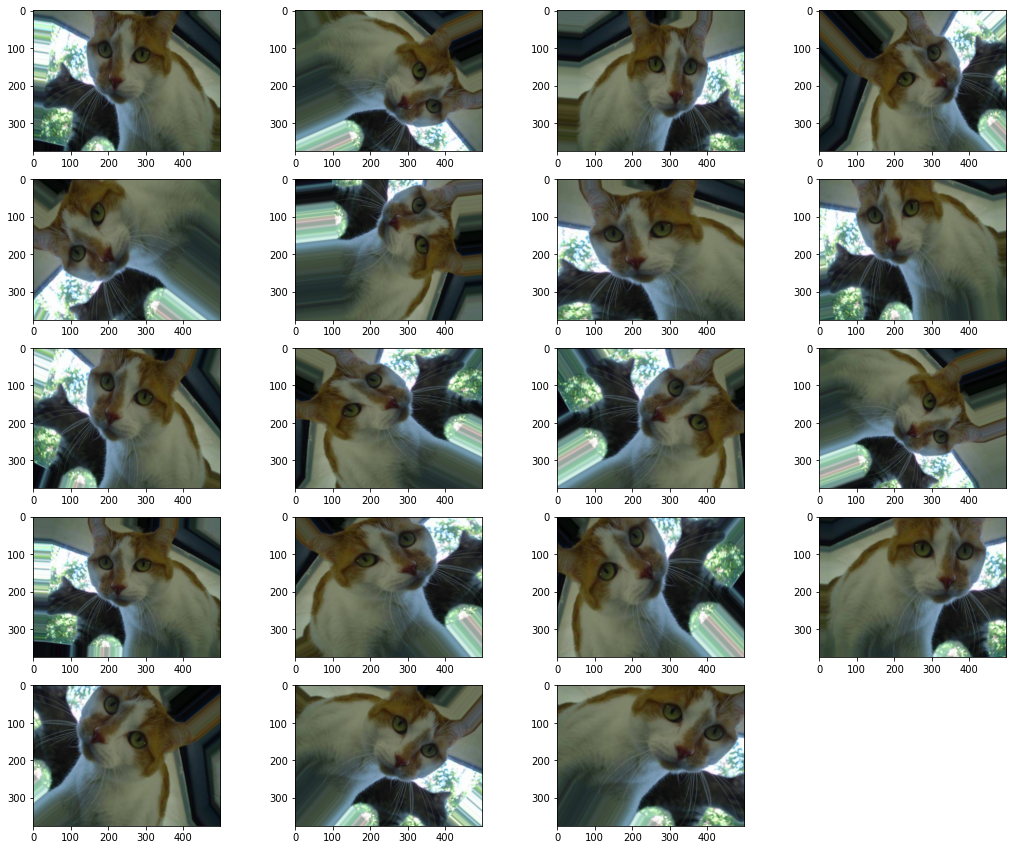

In [21]:
plt.figure(figsize=(18, 15))
for i in range(1, 20):
  plt.subplot(5, 4, i)
  plt.imshow(testI[i-1])